# Thermal Cold-Region Dataset Deep Audit — Fixed Notebook

Run all cells from top to bottom.

This notebook is only for **dataset understanding**, not model training.

It generates the audit CSVs and slide-ready figures:
- `01_file_inventory.csv`
- `02_image_mask_pairing_check.csv`
- `03_patient_subject_case_doctor_try_table.csv`
- `04_duplicate_image_check.csv`
- `05_mask_label_value_check.csv`
- `06_mask_pixel_statistics.csv`
- `07_doctor_agreement_table.csv`
- `08_same_image_12_mask_visualization.png`
- `09_problem_cases.csv`
- `10_audit_summary_for_slides.csv`

In [1]:
# ============================================================
# SECTION 00 — CONFIG
# ============================================================

from pathlib import Path
import os, re, json, math, hashlib, random, warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings("ignore")

ROOT = Path("/media/data/rPPG/rPPG_Data/SHARE/PixelLabelData")
IMG_DIR = ROOT / "FIR_input"
MASK_DIR = ROOT / "PixelLabelData"

OUT_DIR = Path("THERMO_DATASET_AUDIT")
CSV_DIR = OUT_DIR / "csv"
FIG_DIR = OUT_DIR / "figures"
NPZ_DIR = OUT_DIR / "consensus_npz"

for d in [OUT_DIR, CSV_DIR, FIG_DIR, NPZ_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BODY_LABEL_VALUES = [2, 3]
COLD_LABEL_VALUES = [3]

EXPECTED_DOCTORS = 4
EXPECTED_TRIES_PER_DOCTOR = 3
EXPECTED_ANNOTATIONS_PER_IMAGE = EXPECTED_DOCTORS * EXPECTED_TRIES_PER_DOCTOR

random.seed(42)
np.random.seed(42)

print("ROOT:", ROOT)
print("IMG_DIR:", IMG_DIR, "exists:", IMG_DIR.exists())
print("MASK_DIR:", MASK_DIR, "exists:", MASK_DIR.exists())
print("OUT_DIR:", OUT_DIR.resolve())

ROOT: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData
IMG_DIR: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/FIR_input exists: True
MASK_DIR: /media/data/rPPG/rPPG_Data/SHARE/PixelLabelData/PixelLabelData exists: True
OUT_DIR: /home/rafsan/Documents/GitHub/Cool_GANs/THERMO_DATASET_AUDIT


In [2]:
# ============================================================
# SECTION 01 — SAFE HELPERS
# ============================================================

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".npy", ".npz"}

def natural_sort_string(x):
    x = str(x)
    parts = re.split(r"(\d+)", x)
    out = []
    for p in parts:
        if p.isdigit():
            out.append(p.zfill(10))
        else:
            out.append(p.lower())
    return "_".join(out)

def sort_df(df, cols):
    df = df.copy()
    tmp_cols = []
    for col in cols:
        tmp = f"__sort_{col}"
        tmp_cols.append(tmp)
        if col not in df.columns:
            df[tmp] = ""
        elif col in ["doctor_try", "try_id", "annotation_index"]:
            df[tmp] = df[col].apply(lambda x: int(x) if str(x).isdigit() else 999999)
        else:
            df[tmp] = df[col].apply(natural_sort_string)
    df = df.sort_values(tmp_cols).drop(columns=tmp_cols).reset_index(drop=True)
    return df

def list_files(folder):
    folder = Path(folder)
    if not folder.exists():
        return []
    paths = [p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    return sorted(paths, key=lambda p: natural_sort_string(str(p)))

def file_md5(path, chunk_size=1024 * 1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def load_gray(path):
    path = Path(path)
    if path.suffix.lower() == ".npy":
        arr = np.load(path)
        if arr.ndim == 3:
            arr = arr[..., 0]
        return arr.astype(np.float32)
    if path.suffix.lower() == ".npz":
        d = np.load(path)
        first_key = list(d.keys())[0]
        arr = d[first_key]
        if arr.ndim == 3:
            arr = arr[..., 0]
        return arr.astype(np.float32)
    img = Image.open(path)
    arr = np.array(img)
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr.astype(np.float32)

def robust01(x):
    x = np.asarray(x, dtype=np.float32)
    lo, hi = np.nanpercentile(x, [1, 99])
    if hi <= lo:
        lo, hi = np.nanmin(x), np.nanmax(x)
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    return np.clip((x - lo) / (hi - lo), 0, 1).astype(np.float32)

def mask_to_body_cold(mask):
    mask = np.asarray(mask)
    body = np.isin(mask, BODY_LABEL_VALUES)
    cold = np.isin(mask, COLD_LABEL_VALUES)
    return body.astype(bool), cold.astype(bool)

def dice_binary(a, b, eps=1e-8):
    a = np.asarray(a).astype(bool)
    b = np.asarray(b).astype(bool)
    denom = a.sum() + b.sum()
    if denom == 0:
        return np.nan
    inter = np.logical_and(a, b).sum()
    return float((2 * inter + eps) / (denom + eps))

def iou_binary(a, b, eps=1e-8):
    a = np.asarray(a).astype(bool)
    b = np.asarray(b).astype(bool)
    union = np.logical_or(a, b).sum()
    if union == 0:
        return np.nan
    inter = np.logical_and(a, b).sum()
    return float((inter + eps) / (union + eps))

def overlay_mask(img, mask, alpha=0.40):
    img01 = robust01(img)
    rgb = np.stack([img01, img01, img01], axis=-1)
    mask = mask.astype(bool)
    rgb[mask, 0] = (1-alpha) * rgb[mask, 0] + alpha * 1.0
    rgb[mask, 1] = (1-alpha) * rgb[mask, 1]
    rgb[mask, 2] = (1-alpha) * rgb[mask, 2]
    return np.clip(rgb, 0, 1)

def parse_subject_id(name):
    s = str(name)
    m = re.search(r"(S\d+)", s, flags=re.IGNORECASE)
    if m:
        return m.group(1).upper()
    return Path(s).stem.split("-")[0].split("_")[0]

def parse_patient_case_tokens(name):
    stem = Path(str(name)).stem
    norm = re.sub(r"[_\s]+", "-", stem)
    parts = [p for p in norm.split("-") if p != ""]
    subject = parse_subject_id(stem)
    tokens_after_subject = []
    found = False
    for p in parts:
        if re.fullmatch(r"S\d+", p, flags=re.IGNORECASE):
            found = True
            continue
        if found:
            tokens_after_subject.append(p)
    session_token = tokens_after_subject[0] if len(tokens_after_subject) > 0 else "UNK"
    repeat_token = tokens_after_subject[1] if len(tokens_after_subject) > 1 else "UNK"
    return subject, session_token, repeat_token

def parse_doctor_try_from_name(name):
    stem = Path(str(name)).stem
    s = stem.lower()
    doctor = "UNK"
    try_id = "UNK"

    patterns = [
        r"(?:doctor|doc|dr|km|d)[-_ ]?([a-d1-4])",
        r"(?:^|[-_ ])([a-d])(?:[-_ ]|$)",
    ]
    for pat in patterns:
        m = re.search(pat, s)
        if m:
            v = m.group(1).upper()
            doctor = f"D{v}" if v in ["1", "2", "3", "4"] else v
            break

    try_patterns = [
        r"(?:try|trial|t|rep|repeat|r)[-_ ]?(\d+)",
        r"(?:^|[-_ ])(\d+)(?:[-_ ]*$)",
    ]
    for pat in try_patterns:
        m = re.search(pat, s)
        if m:
            try_id = str(int(m.group(1)))
            break

    return doctor, try_id

def infer_doctor_try_from_annotation_index(idx, n_annotations):
    if n_annotations == EXPECTED_ANNOTATIONS_PER_IMAGE:
        doctor_num = idx // EXPECTED_TRIES_PER_DOCTOR + 1
        try_num = idx % EXPECTED_TRIES_PER_DOCTOR + 1
        return f"D{doctor_num}", str(try_num)
    return "GT", str(idx + 1)

def safe_unique_values(arr, max_values=50):
    vals = np.unique(arr)
    if len(vals) > max_values:
        return ",".join(map(str, vals[:max_values])) + f"...(+{len(vals)-max_values})"
    return ",".join(map(str, vals))

print("Helpers ready.")

Helpers ready.


In [3]:
# ============================================================
# SECTION 02 — FILE INVENTORY
# ============================================================

image_paths = list_files(IMG_DIR)
mask_paths = list_files(MASK_DIR)

inventory_rows = []
for kind, paths in [("image", image_paths), ("mask", mask_paths)]:
    for p in paths:
        try:
            arr = load_gray(p)
            shape = tuple(arr.shape)
            min_v = float(np.nanmin(arr))
            max_v = float(np.nanmax(arr))
            unique_preview = safe_unique_values(arr, max_values=20) if kind == "mask" else ""
        except Exception as e:
            shape = ""
            min_v = np.nan
            max_v = np.nan
            unique_preview = ""

        inventory_rows.append({
            "kind": kind,
            "path": str(p),
            "name": p.name,
            "stem": p.stem,
            "suffix": p.suffix.lower(),
            "size_bytes": p.stat().st_size if p.exists() else np.nan,
            "shape": str(shape),
            "min_value": min_v,
            "max_value": max_v,
            "unique_values_preview": unique_preview,
            "subject_id": parse_subject_id(p.name),
        })

inventory_df = pd.DataFrame(inventory_rows)
inventory_df = sort_df(inventory_df, ["kind", "subject_id", "name"])
inventory_df.to_csv(CSV_DIR / "01_file_inventory.csv", index=False)

print("Images:", len(image_paths))
print("Masks:", len(mask_paths))
display(inventory_df.head(20))

Images: 79
Masks: 79


,kind,path,name,stem,suffix,size_bytes,shape,min_value,max_value,unique_values_preview,subject_id
0,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-B-2.bmp,S05-B-2,.bmp,245814,"(256, 320)",0.0,254.0,,S05
1,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-B-3.bmp,S05-B-3,.bmp,245814,"(256, 320)",0.0,254.0,,S05
2,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-1.bmp,S05-C-1,.bmp,245814,"(256, 320)",0.0,254.0,,S05
3,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-2.bmp,S05-C-2,.bmp,245814,"(256, 320)",0.0,254.0,,S05
4,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-3.bmp,S05-C-3,.bmp,245814,"(256, 320)",0.0,254.0,,S05
5,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-1.bmp,S05-D-1,.bmp,245814,"(256, 320)",0.0,254.0,,S05
6,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-2.bmp,S05-D-2,.bmp,245814,"(256, 320)",0.0,254.0,,S05
7,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-3.bmp,S05-D-3,.bmp,245814,"(256, 320)",0.0,254.0,,S05
8,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S06-A-1.bmp,S06-A-1,.bmp,245814,"(256, 320)",0.0,254.0,,S06
9,image,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S06-A-2.bmp,S06-A-2,.bmp,245814,"(256, 320)",0.0,254.0,,S06


In [4]:
# ============================================================
# SECTION 03 — IMAGE-MASK PAIRING AUDIT
# ============================================================

if len(image_paths) == 0 or len(mask_paths) == 0:
    raise RuntimeError("No images or masks found. Check IMG_DIR and MASK_DIR.")

pair_rows = []

if len(mask_paths) % len(image_paths) == 0:
    masks_per_image = len(mask_paths) // len(image_paths)
    pairing_mode = "natural_order_block_pairing"
else:
    masks_per_image = None
    pairing_mode = "natural_order_min_count_pairing"

print("Pairing mode:", pairing_mode)
print("masks_per_image:", masks_per_image)

if masks_per_image is not None:
    for img_idx, img_path in enumerate(image_paths):
        start = img_idx * masks_per_image
        end = start + masks_per_image
        block_masks = mask_paths[start:end]
        subject, session_token, repeat_token = parse_patient_case_tokens(img_path.name)
        image_hash = file_md5(img_path)

        for local_idx, mask_path in enumerate(block_masks):
            doc_from_name, try_from_name = parse_doctor_try_from_name(mask_path.name)

            if doc_from_name == "UNK" and try_from_name == "UNK":
                doctor_id, doctor_try = infer_doctor_try_from_annotation_index(local_idx, masks_per_image)
                doctor_parse_source = "inferred_from_order"
            else:
                doctor_id, doctor_try = doc_from_name, try_from_name
                doctor_parse_source = "parsed_from_filename"

            pair_rows.append({
                "pair_index": len(pair_rows),
                "image_index": img_idx,
                "mask_local_index": local_idx,
                "image_path": str(img_path),
                "mask_path": str(mask_path),
                "image_name": img_path.name,
                "mask_name": mask_path.name,
                "image_stem": img_path.stem,
                "mask_stem": mask_path.stem,
                "subject_id": subject,
                "session_token": session_token,
                "repeat_token": repeat_token,
                "image_hash": image_hash,
                "same_image_group": img_path.stem,
                "doctor_id": doctor_id,
                "doctor_try": doctor_try,
                "doctor_parse_source": doctor_parse_source,
                "masks_per_image_assumption": masks_per_image,
            })
else:
    n = min(len(image_paths), len(mask_paths))
    for i in range(n):
        img_path = image_paths[i]
        mask_path = mask_paths[i]
        subject, session_token, repeat_token = parse_patient_case_tokens(img_path.name)
        doc_from_name, try_from_name = parse_doctor_try_from_name(mask_path.name)
        pair_rows.append({
            "pair_index": len(pair_rows),
            "image_index": i,
            "mask_local_index": 0,
            "image_path": str(img_path),
            "mask_path": str(mask_path),
            "image_name": img_path.name,
            "mask_name": mask_path.name,
            "image_stem": img_path.stem,
            "mask_stem": mask_path.stem,
            "subject_id": subject,
            "session_token": session_token,
            "repeat_token": repeat_token,
            "image_hash": file_md5(img_path),
            "same_image_group": img_path.stem,
            "doctor_id": doc_from_name if doc_from_name != "UNK" else "GT",
            "doctor_try": try_from_name if try_from_name != "UNK" else "1",
            "doctor_parse_source": "parsed_or_single_gt",
            "masks_per_image_assumption": 1,
        })

pair_df = pd.DataFrame(pair_rows)
pair_df["audit_case_id"] = pair_df["same_image_group"].astype(str)
pair_df = sort_df(pair_df, ["subject_id", "audit_case_id", "doctor_id", "doctor_try", "mask_name"])
pair_df["annotation_index"] = pair_df.groupby("audit_case_id").cumcount()
pair_df["n_annotations_for_same_image"] = pair_df.groupby("audit_case_id")["mask_path"].transform("count")

pair_df.to_csv(CSV_DIR / "02_image_mask_pairing_check.csv", index=False)
case_table = pair_df.copy()
case_table.to_csv(CSV_DIR / "03_patient_subject_case_doctor_try_table.csv", index=False)

print("Total pair rows:", len(pair_df))
print("Unique image groups:", pair_df["audit_case_id"].nunique())
display(pair_df["n_annotations_for_same_image"].value_counts().sort_index().reset_index(name="n_image_groups"))
display(pair_df.head(20))

Pairing mode: natural_order_block_pairing
masks_per_image: 1
Total pair rows: 79
Unique image groups: 79


,n_annotations_for_same_image,n_image_groups
0,1,79


,pair_index,image_index,mask_local_index,image_path,mask_path,image_name,mask_name,image_stem,mask_stem,subject_id,...,repeat_token,image_hash,same_image_group,doctor_id,doctor_try,doctor_parse_source,masks_per_image_assumption,audit_case_id,annotation_index,n_annotations_for_same_image
0,0,0,0,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-B-2.bmp,Label_1.png,S05-B-2,Label_1,S05,...,2,2d2d4f1f46406fd2fc03cfcef2960b2a,S05-B-2,UNK,1,parsed_from_filename,1,S05-B-2,0,1
1,1,1,0,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-B-3.bmp,Label_2.png,S05-B-3,Label_2,S05,...,3,2d2ae48e7ebbed48a58adbc32f15c69e,S05-B-3,UNK,2,parsed_from_filename,1,S05-B-3,0,1
2,2,2,0,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-1.bmp,Label_3.png,S05-C-1,Label_3,S05,...,1,b8e49e2cc2bbd32351f3315863c0293b,S05-C-1,UNK,3,parsed_from_filename,1,S05-C-1,0,1
3,3,3,0,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-2.bmp,Label_4.png,S05-C-2,Label_4,S05,...,2,6a96be85a30104382550963cec2739fb,S05-C-2,UNK,4,parsed_from_filename,1,S05-C-2,0,1
4,4,4,0,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-C-3.bmp,Label_5.png,S05-C-3,Label_5,S05,...,3,8fc7f548c6dfcb177a6f8643605108ce,S05-C-3,UNK,5,parsed_from_filename,1,S05-C-3,0,1
5,5,5,0,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-1.bmp,Label_6.png,S05-D-1,Label_6,S05,...,1,9a2583c71ec4d770edb8794dd63a2292,S05-D-1,UNK,6,parsed_from_filename,1,S05-D-1,0,1
6,6,6,0,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-2.bmp,Label_7.png,S05-D-2,Label_7,S05,...,2,457ae3c453350b50963e29f803616334,S05-D-2,UNK,7,parsed_from_filename,1,S05-D-2,0,1
7,7,7,0,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S05-D-3.bmp,Label_8.png,S05-D-3,Label_8,S05,...,3,9c6bf417188a4dbd12f0287ebf9065ad,S05-D-3,UNK,8,parsed_from_filename,1,S05-D-3,0,1
8,8,8,0,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S06-A-1.bmp,Label_9.png,S06-A-1,Label_9,S06,...,1,73deb26554f2102d1931af3c8b518773,S06-A-1,UNK,9,parsed_from_filename,1,S06-A-1,0,1
9,9,9,0,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,S06-A-2.bmp,Label_10.png,S06-A-2,Label_10,S06,...,2,ab43d0e723106532501f41fec177bf54,S06-A-2,UNK,10,parsed_from_filename,1,S06-A-2,0,1


In [5]:
# ============================================================
# SECTION 04 — DUPLICATE IMAGE CHECK
# ============================================================

image_hash_rows = []
for p in image_paths:
    image_hash_rows.append({
        "image_path": str(p),
        "image_name": p.name,
        "subject_id": parse_subject_id(p.name),
        "image_hash": file_md5(p),
    })

dup_df = pd.DataFrame(image_hash_rows)
dup_df["duplicate_group_size"] = dup_df.groupby("image_hash")["image_path"].transform("count")
dup_df["is_duplicate_image_content"] = dup_df["duplicate_group_size"] > 1
dup_df = sort_df(dup_df, ["subject_id", "image_name"])
dup_df.to_csv(CSV_DIR / "04_duplicate_image_check.csv", index=False)

display(dup_df[dup_df["is_duplicate_image_content"]].head(30))

,image_path,image_name,subject_id,image_hash,duplicate_group_size,is_duplicate_image_content


In [6]:
# ============================================================
# SECTION 05 — MASK LABEL VALUES + PIXEL STATISTICS
# ============================================================

label_rows = []
pixel_rows = []

for _, row in pair_df.iterrows():
    img_path = Path(row["image_path"])
    mask_path = Path(row["mask_path"])
    problem_notes = []

    try:
        img = load_gray(img_path)
        mask = load_gray(mask_path)
        mask_int = np.rint(mask).astype(np.int32)

        if img.shape != mask_int.shape:
            problem_notes.append(f"shape_mismatch_img{img.shape}_mask{mask_int.shape}")

        vals, counts = np.unique(mask_int, return_counts=True)
        label_count_dict = {int(v): int(c) for v, c in zip(vals, counts)}

        body, cold = mask_to_body_cold(mask_int)
        n_pixels = mask_int.size
        body_pixels = int(body.sum())
        cold_pixels = int(cold.sum())

        unknown_labels = [int(v) for v in vals if int(v) not in [0, 1, 2, 3]]
        if len(unknown_labels) > 0:
            problem_notes.append(f"unknown_labels_{unknown_labels}")
        if body_pixels == 0:
            problem_notes.append("empty_body")
        if cold_pixels == 0:
            problem_notes.append("empty_cold")
        if cold_pixels > body_pixels and body_pixels > 0:
            problem_notes.append("cold_larger_than_body")

        label_rows.append({
            "pair_index": row["pair_index"],
            "audit_case_id": row["audit_case_id"],
            "subject_id": row["subject_id"],
            "doctor_id": row["doctor_id"],
            "doctor_try": row["doctor_try"],
            "image_name": row["image_name"],
            "mask_name": row["mask_name"],
            "mask_path": row["mask_path"],
            "mask_shape": str(mask_int.shape),
            "unique_values": ",".join(map(str, vals.tolist())),
            "label_counts_json": json.dumps(label_count_dict),
            "unknown_labels": ",".join(map(str, unknown_labels)),
            "problem_notes": ";".join(problem_notes),
        })

        pixel_rows.append({
            "pair_index": row["pair_index"],
            "audit_case_id": row["audit_case_id"],
            "subject_id": row["subject_id"],
            "session_token": row["session_token"],
            "repeat_token": row["repeat_token"],
            "doctor_id": row["doctor_id"],
            "doctor_try": row["doctor_try"],
            "image_name": row["image_name"],
            "mask_name": row["mask_name"],
            "image_path": row["image_path"],
            "mask_path": row["mask_path"],
            "n_pixels": n_pixels,
            "body_pixels": body_pixels,
            "cold_pixels": cold_pixels,
            "body_fraction_image": body_pixels / (n_pixels + 1e-8),
            "cold_fraction_image": cold_pixels / (n_pixels + 1e-8),
            "cold_fraction_in_body": cold_pixels / (body_pixels + 1e-8),
            "problem_notes": ";".join(problem_notes),
        })

    except Exception as e:
        label_rows.append({
            "pair_index": row["pair_index"],
            "audit_case_id": row["audit_case_id"],
            "subject_id": row["subject_id"],
            "doctor_id": row["doctor_id"],
            "doctor_try": row["doctor_try"],
            "image_name": row["image_name"],
            "mask_name": row["mask_name"],
            "mask_path": row["mask_path"],
            "mask_shape": "",
            "unique_values": "",
            "label_counts_json": "{}",
            "unknown_labels": "",
            "problem_notes": f"read_error_{repr(e)}",
        })

mask_label_df = pd.DataFrame(label_rows)
pixel_df = pd.DataFrame(pixel_rows)

mask_label_df = sort_df(mask_label_df, ["subject_id", "audit_case_id", "doctor_id", "doctor_try", "mask_name"])
pixel_df = sort_df(pixel_df, ["subject_id", "audit_case_id", "doctor_id", "doctor_try", "mask_name"])

mask_label_df.to_csv(CSV_DIR / "05_mask_label_value_check.csv", index=False)
pixel_df.to_csv(CSV_DIR / "06_mask_pixel_statistics.csv", index=False)

display(mask_label_df.head(20))
display(pixel_df.groupby("subject_id")[["body_pixels", "cold_pixels", "cold_fraction_in_body"]].mean().reset_index())

,pair_index,audit_case_id,subject_id,doctor_id,doctor_try,image_name,mask_name,mask_path,mask_shape,unique_values,label_counts_json,unknown_labels,problem_notes
0,0,S05-B-2,S05,UNK,1,S05-B-2.bmp,Label_1.png,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,"(256, 320)","0,1,2,3","{""0"": 1, ""1"": 52688, ""2"": 25152, ""3"": 4079}",,
1,1,S05-B-3,S05,UNK,2,S05-B-3.bmp,Label_2.png,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,"(256, 320)","1,2,3","{""1"": 52893, ""2"": 26703, ""3"": 2324}",,
2,2,S05-C-1,S05,UNK,3,S05-C-1.bmp,Label_3.png,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,"(256, 320)","1,2,3","{""1"": 52596, ""2"": 28453, ""3"": 871}",,
3,3,S05-C-2,S05,UNK,4,S05-C-2.bmp,Label_4.png,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,"(256, 320)","0,1,2,3","{""0"": 76, ""1"": 53810, ""2"": 27480, ""3"": 554}",,
4,4,S05-C-3,S05,UNK,5,S05-C-3.bmp,Label_5.png,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,"(256, 320)","1,2,3","{""1"": 52767, ""2"": 28545, ""3"": 608}",,
5,5,S05-D-1,S05,UNK,6,S05-D-1.bmp,Label_6.png,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,"(256, 320)","1,2,3","{""1"": 51572, ""2"": 30044, ""3"": 304}",,
6,6,S05-D-2,S05,UNK,7,S05-D-2.bmp,Label_7.png,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,"(256, 320)","1,2,3","{""1"": 52327, ""2"": 29025, ""3"": 568}",,
7,7,S05-D-3,S05,UNK,8,S05-D-3.bmp,Label_8.png,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,"(256, 320)","1,2,3","{""1"": 50920, ""2"": 29721, ""3"": 1279}",,
8,8,S06-A-1,S06,UNK,9,S06-A-1.bmp,Label_9.png,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,"(256, 320)","1,2,3","{""1"": 67132, ""2"": 4951, ""3"": 9837}",,
9,9,S06-A-2,S06,UNK,10,S06-A-2.bmp,Label_10.png,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,"(256, 320)","1,2,3","{""1"": 65908, ""2"": 15304, ""3"": 708}",,


,subject_id,body_pixels,cold_pixels,cold_fraction_in_body
0,S05,29463.750000,1323.375000,0.045049
1,S06,15443.090909,1402.363636,0.093053
2,S07,16550.083333,1560.916667,0.101660
3,S08,16078.000000,416.833333,0.024338
4,S09,13150.416667,333.750000,0.024902
5,S10,9318.916667,260.083333,0.028654
6,S11,13192.000000,2032.000000,0.154706


In [7]:
# ============================================================
# SECTION 06 — DOCTOR AGREEMENT + SOFT CONSENSUS
# ============================================================

agreement_rows = []
consensus_index_rows = []

for audit_case_id, g in pair_df.groupby("audit_case_id"):
    g = sort_df(g, ["doctor_id", "doctor_try", "mask_name"])
    img_path = Path(g["image_path"].iloc[0])

    try:
        img = load_gray(img_path)
    except Exception:
        continue

    masks_cold = []
    masks_body = []
    meta_rows = []
    shape_ok = True
    base_shape = None

    for _, r in g.iterrows():
        try:
            mask = np.rint(load_gray(r["mask_path"])).astype(np.int32)
            if base_shape is None:
                base_shape = mask.shape
            if mask.shape != base_shape:
                shape_ok = False
                continue
            body, cold = mask_to_body_cold(mask)
            masks_body.append(body.astype(np.float32))
            masks_cold.append(cold.astype(np.float32))
            meta_rows.append(r)
        except Exception:
            shape_ok = False

    n_ann = len(masks_cold)
    if n_ann == 0:
        continue

    cold_stack = np.stack(masks_cold, axis=0)
    body_stack = np.stack(masks_body, axis=0)

    cold_soft = cold_stack.mean(axis=0).astype(np.float32)
    body_soft = body_stack.mean(axis=0).astype(np.float32)
    cold_uncertainty = (4.0 * cold_soft * (1.0 - cold_soft)).astype(np.float32)
    body_uncertainty = (4.0 * body_soft * (1.0 - body_soft)).astype(np.float32)

    pair_dices = []
    pair_ious = []
    for i, j in combinations(range(n_ann), 2):
        pair_dices.append(dice_binary(cold_stack[i], cold_stack[j]))
        pair_ious.append(iou_binary(cold_stack[i], cold_stack[j]))

    mean_pairwise_cold_dice = float(np.nanmean(pair_dices)) if len(pair_dices) else np.nan
    mean_pairwise_cold_iou = float(np.nanmean(pair_ious)) if len(pair_ious) else np.nan

    subject_id = g["subject_id"].iloc[0]
    npz_path = NPZ_DIR / f"{audit_case_id}.npz"
    np.savez_compressed(
        npz_path,
        img=img.astype(np.float32),
        body_soft=body_soft,
        cold_soft=cold_soft,
        body_uncertainty=body_uncertainty,
        cold_uncertainty=cold_uncertainty,
        n_annotations=np.array([n_ann], dtype=np.int32),
    )

    consensus_index_rows.append({
        "audit_case_id": audit_case_id,
        "subject_id": subject_id,
        "image_path": str(img_path),
        "npz_path": str(npz_path),
        "n_annotations": n_ann,
        "n_doctors": g["doctor_id"].nunique(),
        "n_tries": g["doctor_try"].nunique(),
        "mean_cold_soft": float(cold_soft.mean()),
        "sum_cold_soft": float(cold_soft.sum()),
        "mean_body_soft": float(body_soft.mean()),
        "sum_body_soft": float(body_soft.sum()),
        "mean_cold_uncertainty": float(cold_uncertainty.mean()),
        "mean_body_uncertainty": float(body_uncertainty.mean()),
        "mean_pairwise_cold_dice": mean_pairwise_cold_dice,
        "mean_pairwise_cold_iou": mean_pairwise_cold_iou,
        "shape_ok": shape_ok,
    })

    for doctor_id, dg in g.groupby("doctor_id"):
        d_indices = [idx for idx, mr in enumerate(meta_rows) if str(mr["doctor_id"]) == str(doctor_id)]
        if len(d_indices) == 0:
            continue
        d_cold = cold_stack[d_indices].mean(axis=0)
        d_body = body_stack[d_indices].mean(axis=0)

        agreement_rows.append({
            "audit_case_id": audit_case_id,
            "subject_id": subject_id,
            "doctor_id": doctor_id,
            "n_annotations_total": n_ann,
            "n_annotations_doctor": len(d_indices),
            "doctor_cold_pixels_mean": float(d_cold.sum()),
            "doctor_body_pixels_mean": float(d_body.sum()),
            "doctor_cold_fraction_in_body": float(d_cold.sum() / (d_body.sum() + 1e-8)),
            "case_mean_pairwise_cold_dice": mean_pairwise_cold_dice,
            "case_mean_pairwise_cold_iou": mean_pairwise_cold_iou,
            "case_mean_cold_uncertainty": float(cold_uncertainty.mean()),
        })

agreement_df = pd.DataFrame(agreement_rows)
consensus_df = pd.DataFrame(consensus_index_rows)

if len(agreement_df):
    agreement_df = sort_df(agreement_df, ["subject_id", "audit_case_id", "doctor_id"])
if len(consensus_df):
    consensus_df = sort_df(consensus_df, ["subject_id", "audit_case_id"])

agreement_df.to_csv(CSV_DIR / "07_doctor_agreement_table.csv", index=False)
consensus_df.to_csv(CSV_DIR / "07b_consensus_cache_index.csv", index=False)

display(consensus_df.head(20))
display(agreement_df.head(20))

,audit_case_id,subject_id,image_path,npz_path,n_annotations,n_doctors,n_tries,mean_cold_soft,sum_cold_soft,mean_body_soft,sum_body_soft,mean_cold_uncertainty,mean_body_uncertainty,mean_pairwise_cold_dice,mean_pairwise_cold_iou,shape_ok
0,S05-B-2,S05,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,THERMO_DATASET_AUDIT/consensus_npz/S05-B-2.npz,1,1,1,0.049792,4079.0,0.356824,29231.0,0.0,0.0,NaN,NaN,True
1,S05-B-3,S05,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,THERMO_DATASET_AUDIT/consensus_npz/S05-B-3.npz,1,1,1,0.028369,2324.0,0.354333,29027.0,0.0,0.0,NaN,NaN,True
2,S05-C-1,S05,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,THERMO_DATASET_AUDIT/consensus_npz/S05-C-1.npz,1,1,1,0.010632,871.0,0.357959,29324.0,0.0,0.0,NaN,NaN,True
3,S05-C-2,S05,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,THERMO_DATASET_AUDIT/consensus_npz/S05-C-2.npz,1,1,1,0.006763,554.0,0.342212,28034.0,0.0,0.0,NaN,NaN,True
4,S05-C-3,S05,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,THERMO_DATASET_AUDIT/consensus_npz/S05-C-3.npz,1,1,1,0.007422,608.0,0.355872,29153.0,0.0,0.0,NaN,NaN,True
5,S05-D-1,S05,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,THERMO_DATASET_AUDIT/consensus_npz/S05-D-1.npz,1,1,1,0.003711,304.0,0.370459,30348.0,0.0,0.0,NaN,NaN,True
6,S05-D-2,S05,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,THERMO_DATASET_AUDIT/consensus_npz/S05-D-2.npz,1,1,1,0.006934,568.0,0.361243,29593.0,0.0,0.0,NaN,NaN,True
7,S05-D-3,S05,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,THERMO_DATASET_AUDIT/consensus_npz/S05-D-3.npz,1,1,1,0.015613,1279.0,0.378418,31000.0,0.0,0.0,NaN,NaN,True
8,S06-A-1,S06,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,THERMO_DATASET_AUDIT/consensus_npz/S06-A-1.npz,1,1,1,0.120081,9837.0,0.180518,14788.0,0.0,0.0,NaN,NaN,True
9,S06-A-2,S06,/media/data/rPPG/rPPG_Data/SHARE/PixelLabelDat...,THERMO_DATASET_AUDIT/consensus_npz/S06-A-2.npz,1,1,1,0.008643,708.0,0.195459,16012.0,0.0,0.0,NaN,NaN,True


,audit_case_id,subject_id,doctor_id,n_annotations_total,n_annotations_doctor,doctor_cold_pixels_mean,doctor_body_pixels_mean,doctor_cold_fraction_in_body,case_mean_pairwise_cold_dice,case_mean_pairwise_cold_iou,case_mean_cold_uncertainty
0,S05-B-2,S05,UNK,1,1,4079.0,29231.0,0.139544,NaN,NaN,0.0
1,S05-B-3,S05,UNK,1,1,2324.0,29027.0,0.080063,NaN,NaN,0.0
2,S05-C-1,S05,UNK,1,1,871.0,29324.0,0.029703,NaN,NaN,0.0
3,S05-C-2,S05,UNK,1,1,554.0,28034.0,0.019762,NaN,NaN,0.0
4,S05-C-3,S05,UNK,1,1,608.0,29153.0,0.020855,NaN,NaN,0.0
5,S05-D-1,S05,UNK,1,1,304.0,30348.0,0.010017,NaN,NaN,0.0
6,S05-D-2,S05,UNK,1,1,568.0,29593.0,0.019194,NaN,NaN,0.0
7,S05-D-3,S05,UNK,1,1,1279.0,31000.0,0.041258,NaN,NaN,0.0
8,S06-A-1,S06,UNK,1,1,9837.0,14788.0,0.665201,NaN,NaN,0.0
9,S06-A-2,S06,UNK,1,1,708.0,16012.0,0.044217,NaN,NaN,0.0


In [8]:
# ============================================================
# SECTION 07 — PROBLEM CASES
# ============================================================

problem_rows = []

if len(pixel_df):
    for _, r in pixel_df.iterrows():
        notes = []
        if str(r.get("problem_notes", "")) not in ["", "nan"]:
            notes.append(str(r["problem_notes"]))
        if r["body_pixels"] == 0:
            notes.append("empty_body")
        if r["cold_pixels"] == 0:
            notes.append("empty_cold")
        if r["cold_fraction_in_body"] > 0.50:
            notes.append("very_large_cold_fraction_in_body")
        if r["cold_pixels"] > 0 and r["cold_pixels"] < 50:
            notes.append("very_tiny_cold_region")
        if len(notes):
            problem_rows.append({
                "source": "mask_pixel_qc",
                "audit_case_id": r["audit_case_id"],
                "subject_id": r["subject_id"],
                "doctor_id": r["doctor_id"],
                "doctor_try": r["doctor_try"],
                "image_name": r["image_name"],
                "mask_name": r["mask_name"],
                "body_pixels": r["body_pixels"],
                "cold_pixels": r["cold_pixels"],
                "problem_type": ";".join(sorted(set(notes))),
            })

if "consensus_df" in globals() and len(consensus_df):
    for _, r in consensus_df.iterrows():
        notes = []
        if r["n_annotations"] != EXPECTED_ANNOTATIONS_PER_IMAGE:
            notes.append(f"unexpected_annotation_count_{int(r['n_annotations'])}")
        if pd.notna(r["mean_pairwise_cold_dice"]) and r["mean_pairwise_cold_dice"] < 0.20:
            notes.append("low_pairwise_cold_dice")
        if not bool(r["shape_ok"]):
            notes.append("shape_problem_in_group")
        if len(notes):
            problem_rows.append({
                "source": "consensus_qc",
                "audit_case_id": r["audit_case_id"],
                "subject_id": r["subject_id"],
                "doctor_id": "",
                "doctor_try": "",
                "image_name": Path(r["image_path"]).name,
                "mask_name": "",
                "body_pixels": r["sum_body_soft"],
                "cold_pixels": r["sum_cold_soft"],
                "problem_type": ";".join(notes),
            })

problem_df = pd.DataFrame(problem_rows)
if len(problem_df):
    problem_df = sort_df(problem_df, ["subject_id", "audit_case_id", "doctor_id", "doctor_try"])
problem_df.to_csv(CSV_DIR / "09_problem_cases.csv", index=False)

print("Problem cases:", len(problem_df))
display(problem_df.head(30))

Problem cases: 136


,source,audit_case_id,subject_id,doctor_id,doctor_try,image_name,mask_name,body_pixels,cold_pixels,problem_type
0,consensus_qc,S05-B-2,S05,,,S05-B-2.bmp,,29231.0,4079.0,unexpected_annotation_count_1
1,consensus_qc,S05-B-3,S05,,,S05-B-3.bmp,,29027.0,2324.0,unexpected_annotation_count_1
2,consensus_qc,S05-C-1,S05,,,S05-C-1.bmp,,29324.0,871.0,unexpected_annotation_count_1
3,consensus_qc,S05-C-2,S05,,,S05-C-2.bmp,,28034.0,554.0,unexpected_annotation_count_1
4,consensus_qc,S05-C-3,S05,,,S05-C-3.bmp,,29153.0,608.0,unexpected_annotation_count_1
5,consensus_qc,S05-D-1,S05,,,S05-D-1.bmp,,30348.0,304.0,unexpected_annotation_count_1
6,consensus_qc,S05-D-2,S05,,,S05-D-2.bmp,,29593.0,568.0,unexpected_annotation_count_1
7,consensus_qc,S05-D-3,S05,,,S05-D-3.bmp,,31000.0,1279.0,unexpected_annotation_count_1
8,consensus_qc,S06-A-1,S06,,,S06-A-1.bmp,,14788.0,9837.0,unexpected_annotation_count_1
9,mask_pixel_qc,S06-A-1,S06,UNK,9,S06-A-1.bmp,Label_9.png,14788.0,9837.0,very_large_cold_fraction_in_body


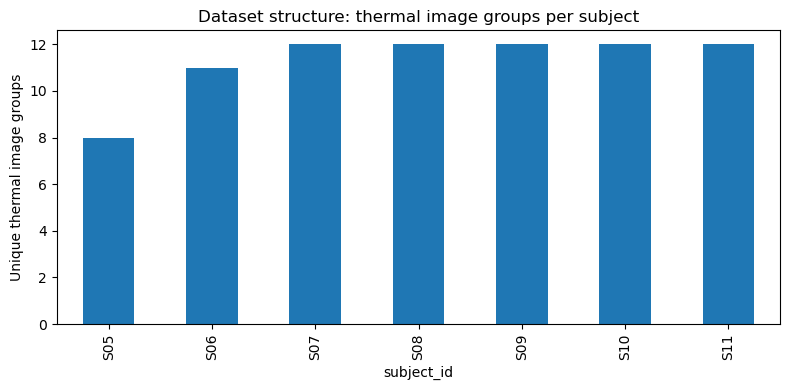

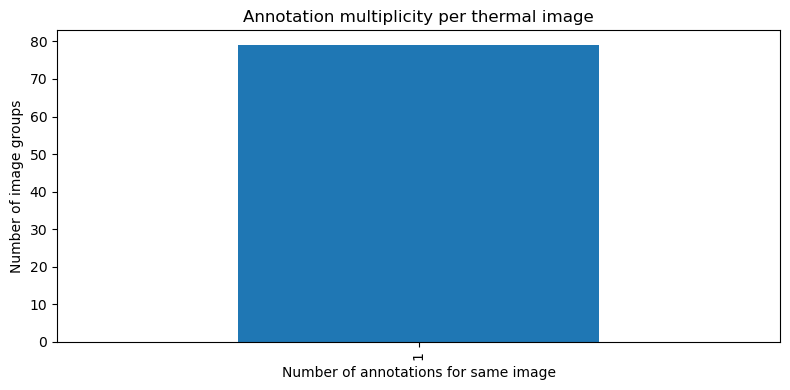

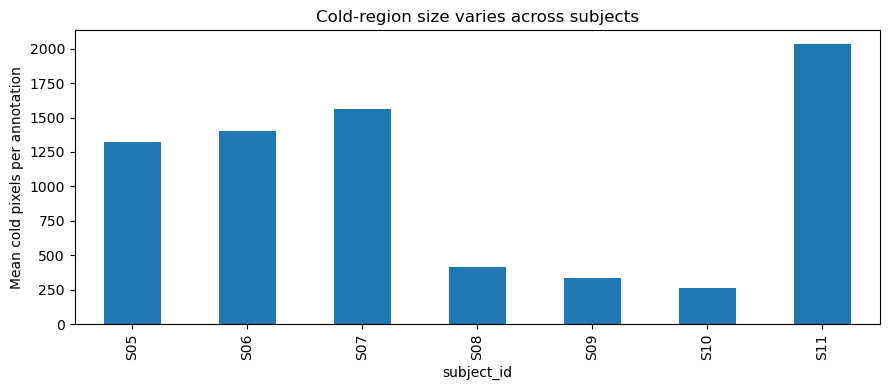

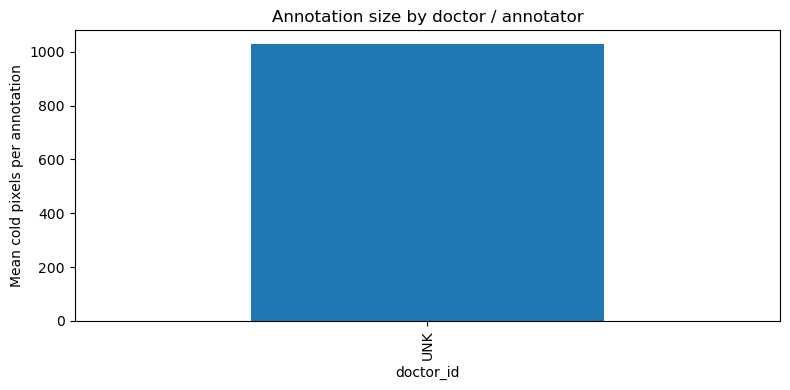

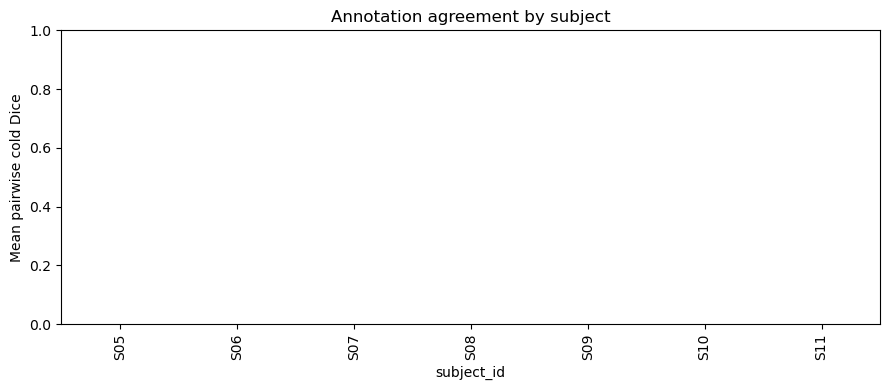

Saved basic slide figures.


In [9]:
# ============================================================
# SECTION 08 — BASIC SLIDE FIGURES
# ============================================================

plt.figure(figsize=(8, 4))
case_table.groupby("subject_id")["audit_case_id"].nunique().sort_index().plot(kind="bar")
plt.ylabel("Unique thermal image groups")
plt.title("Dataset structure: thermal image groups per subject")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01_cases_per_subject.png", dpi=220)
plt.show()

plt.figure(figsize=(8, 4))
case_table.groupby("audit_case_id")["mask_path"].count().value_counts().sort_index().plot(kind="bar")
plt.xlabel("Number of annotations for same image")
plt.ylabel("Number of image groups")
plt.title("Annotation multiplicity per thermal image")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_02_annotations_per_same_image.png", dpi=220)
plt.show()

plt.figure(figsize=(9, 4))
pixel_df.groupby("subject_id")["cold_pixels"].mean().sort_index().plot(kind="bar")
plt.ylabel("Mean cold pixels per annotation")
plt.title("Cold-region size varies across subjects")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_03_mean_cold_pixels_by_subject.png", dpi=220)
plt.show()

plt.figure(figsize=(8, 4))
pixel_df.groupby("doctor_id")["cold_pixels"].mean().sort_index().plot(kind="bar")
plt.ylabel("Mean cold pixels per annotation")
plt.title("Annotation size by doctor / annotator")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_04_mean_cold_pixels_by_doctor.png", dpi=220)
plt.show()

if len(consensus_df) and "mean_pairwise_cold_dice" in consensus_df.columns:
    plt.figure(figsize=(9, 4))
    consensus_df.groupby("subject_id")["mean_pairwise_cold_dice"].mean().sort_index().plot(kind="bar")
    plt.ylabel("Mean pairwise cold Dice")
    plt.ylim(0, 1)
    plt.title("Annotation agreement by subject")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig_05_agreement_by_subject.png", dpi=220)
    plt.show()

print("Saved basic slide figures.")

In [10]:
# ============================================================
# SECTION 09 — VISUALIZATION FUNCTIONS
# ============================================================

def get_good_audit_case(min_annotations=2):
    counts = case_table.groupby("audit_case_id")["mask_path"].count().sort_values(ascending=False)
    counts = counts[counts >= min_annotations]
    if len(counts) == 0:
        return case_table["audit_case_id"].iloc[0]
    return counts.index[0]

def draw_mask_panel(ax, img, mask, title):
    ax.imshow(overlay_mask(img, mask), interpolation="nearest")
    ax.set_title(title, fontsize=9)
    ax.axis("off")

def visualize_same_image_annotations(audit_case_id=None, max_annotations=12):
    if audit_case_id is None:
        audit_case_id = get_good_audit_case(min_annotations=2)

    g = pair_df[pair_df["audit_case_id"] == audit_case_id].copy()
    if len(g) == 0:
        print("No rows for audit_case_id:", audit_case_id)
        return None

    g = sort_df(g, ["doctor_id", "doctor_try", "mask_name"]).head(max_annotations)
    img = load_gray(g["image_path"].iloc[0])

    n = len(g)
    cols = min(4, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows + 1, cols, figsize=(4 * cols, 4 * (rows + 1)))
    axes = np.array(axes).reshape(rows + 1, cols)

    for ax in axes.ravel():
        ax.axis("off")

    axes[0, 0].imshow(robust01(img), cmap="gray")
    axes[0, 0].set_title(f"Thermal image\n{audit_case_id}", fontsize=10)
    axes[0, 0].axis("off")

    masks = []
    for _, r in g.iterrows():
        mask = np.rint(load_gray(r["mask_path"])).astype(np.int32)
        _, cold = mask_to_body_cold(mask)
        masks.append(cold.astype(np.float32))

    cold_soft = np.stack(masks).mean(axis=0)
    axes[0, 1].imshow(cold_soft, cmap="magma", vmin=0, vmax=1)
    axes[0, 1].set_title("Soft consensus", fontsize=10)
    axes[0, 1].axis("off")

    if cols > 2:
        unc = 4 * cold_soft * (1 - cold_soft)
        axes[0, 2].imshow(unc, cmap="viridis", vmin=0, vmax=1)
        axes[0, 2].set_title("Uncertainty", fontsize=10)
        axes[0, 2].axis("off")

    for idx, (_, r) in enumerate(g.iterrows()):
        rr = idx // cols + 1
        cc = idx % cols
        mask = np.rint(load_gray(r["mask_path"])).astype(np.int32)
        _, cold = mask_to_body_cold(mask)
        title = f"{r['doctor_id']} try {r['doctor_try']}\nCold px={int(cold.sum())}"
        draw_mask_panel(axes[rr, cc], img, cold, title)

    plt.suptitle("Same thermal image: annotation variation", fontsize=15)
    plt.tight_layout()
    save_path = FIG_DIR / "08_same_image_12_mask_visualization.png"
    plt.savefig(save_path, dpi=220)
    plt.show()
    print("Saved:", save_path)
    return save_path

def visualize_subject_across_doctors(subject_id=None):
    if subject_id is None:
        subject_id = case_table["subject_id"].value_counts().index[0]

    sub = case_table[case_table["subject_id"] == subject_id].copy()
    if len(sub) == 0:
        print("No rows for subject:", subject_id)
        return None

    audit_case_id = sub["audit_case_id"].value_counts().index[0]
    g = pair_df[pair_df["audit_case_id"] == audit_case_id].copy()
    g = sort_df(g, ["doctor_id", "doctor_try", "mask_name"])

    img = load_gray(g["image_path"].iloc[0])
    doctors = sorted(g["doctor_id"].unique(), key=natural_sort_string)

    cols = len(doctors) + 1
    fig, axes = plt.subplots(1, cols, figsize=(4 * cols, 4))
    if cols == 1:
        axes = [axes]

    axes[0].imshow(robust01(img), cmap="gray")
    axes[0].set_title(f"Image\n{audit_case_id}")
    axes[0].axis("off")

    for i, doc in enumerate(doctors):
        dg = g[g["doctor_id"] == doc].copy()
        masks = []
        for _, r in dg.iterrows():
            mask = np.rint(load_gray(r["mask_path"])).astype(np.int32)
            _, cold = mask_to_body_cold(mask)
            masks.append(cold.astype(np.float32))
        cold_mean = np.stack(masks).mean(axis=0) >= 0.5
        draw_mask_panel(axes[i + 1], img, cold_mean, f"Doctor {doc}\nmean over tries")

    plt.suptitle(f"Subject {subject_id}: doctor-wise annotation difference", fontsize=14)
    plt.tight_layout()
    save_path = FIG_DIR / f"fig_06_subject_{subject_id}_across_doctors.png"
    plt.savefig(save_path, dpi=220)
    plt.show()
    print("Saved:", save_path)
    return save_path

def visualize_one_doctor_across_patients(doctor_id=None, max_cases=8):
    if doctor_id is None:
        doctor_id = pixel_df["doctor_id"].value_counts().index[0]

    sub = pair_df[pair_df["doctor_id"] == doctor_id].copy()
    if len(sub) == 0:
        print("No rows for doctor:", doctor_id)
        return None

    sub = sort_df(sub, ["subject_id", "audit_case_id", "doctor_try", "mask_name"])
    sub = sub.groupby("audit_case_id").head(1).head(max_cases)

    n = len(sub)
    cols = min(4, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax in axes.ravel():
        ax.axis("off")

    for idx, (_, r) in enumerate(sub.iterrows()):
        rr = idx // cols
        cc = idx % cols
        img = load_gray(r["image_path"])
        mask = np.rint(load_gray(r["mask_path"])).astype(np.int32)
        _, cold = mask_to_body_cold(mask)
        draw_mask_panel(axes[rr, cc], img, cold, f"{r['subject_id']} | {r['audit_case_id']}\nCold px={int(cold.sum())}")

    plt.suptitle(f"Doctor {doctor_id}: annotation pattern across patients", fontsize=14)
    plt.tight_layout()
    save_path = FIG_DIR / f"fig_07_doctor_{doctor_id}_across_patients.png"
    plt.savefig(save_path, dpi=220)
    plt.show()
    print("Saved:", save_path)
    return save_path

def visualize_one_subject_one_doctor_tries(subject_id=None, doctor_id=None):
    df = pair_df.copy()

    if subject_id is None:
        subject_id = df["subject_id"].value_counts().index[0]
    df = df[df["subject_id"] == subject_id].copy()

    if doctor_id is None:
        doctor_id = df["doctor_id"].value_counts().index[0]
    df = df[df["doctor_id"] == doctor_id].copy()

    counts = df.groupby("audit_case_id")["mask_path"].count().sort_values(ascending=False)
    if len(counts) == 0:
        print("No rows found.")
        return None

    audit_case_id = counts.index[0]
    g = df[df["audit_case_id"] == audit_case_id].copy()
    g = sort_df(g, ["doctor_try", "mask_name"])

    img = load_gray(g["image_path"].iloc[0])
    n = len(g)
    cols = min(3, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax in axes.ravel():
        ax.axis("off")

    for idx, (_, r) in enumerate(g.iterrows()):
        rr = idx // cols
        cc = idx % cols
        mask = np.rint(load_gray(r["mask_path"])).astype(np.int32)
        _, cold = mask_to_body_cold(mask)
        draw_mask_panel(axes[rr, cc], img, cold, f"{subject_id}, Doctor {doctor_id}\nTry {r['doctor_try']} | cold px={int(cold.sum())}")

    plt.suptitle("Same subject + same doctor: repeated annotation variation", fontsize=14)
    plt.tight_layout()
    save_path = FIG_DIR / f"fig_08_subject_{subject_id}_doctor_{doctor_id}_tries.png"
    plt.savefig(save_path, dpi=220)
    plt.show()
    print("Saved:", save_path)
    return save_path

print("Visualization functions ready.")

Visualization functions ready.


IndexError: index 1 is out of bounds for axis 1 with size 1

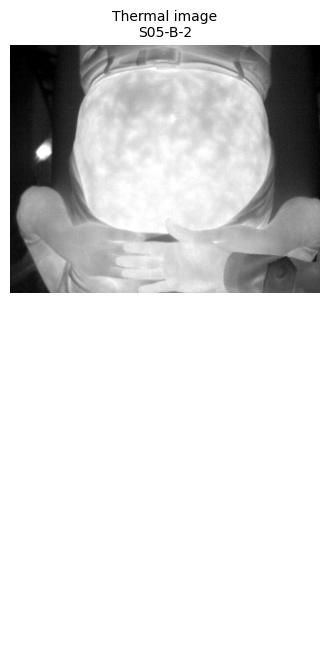

In [11]:
# ============================================================
# SECTION 10 — GENERATE SLIDE-READY VISUALIZATIONS
# ============================================================

visualize_same_image_annotations()
visualize_subject_across_doctors()
visualize_one_doctor_across_patients()
visualize_one_subject_one_doctor_tries()

print("Generated key slide figures.")

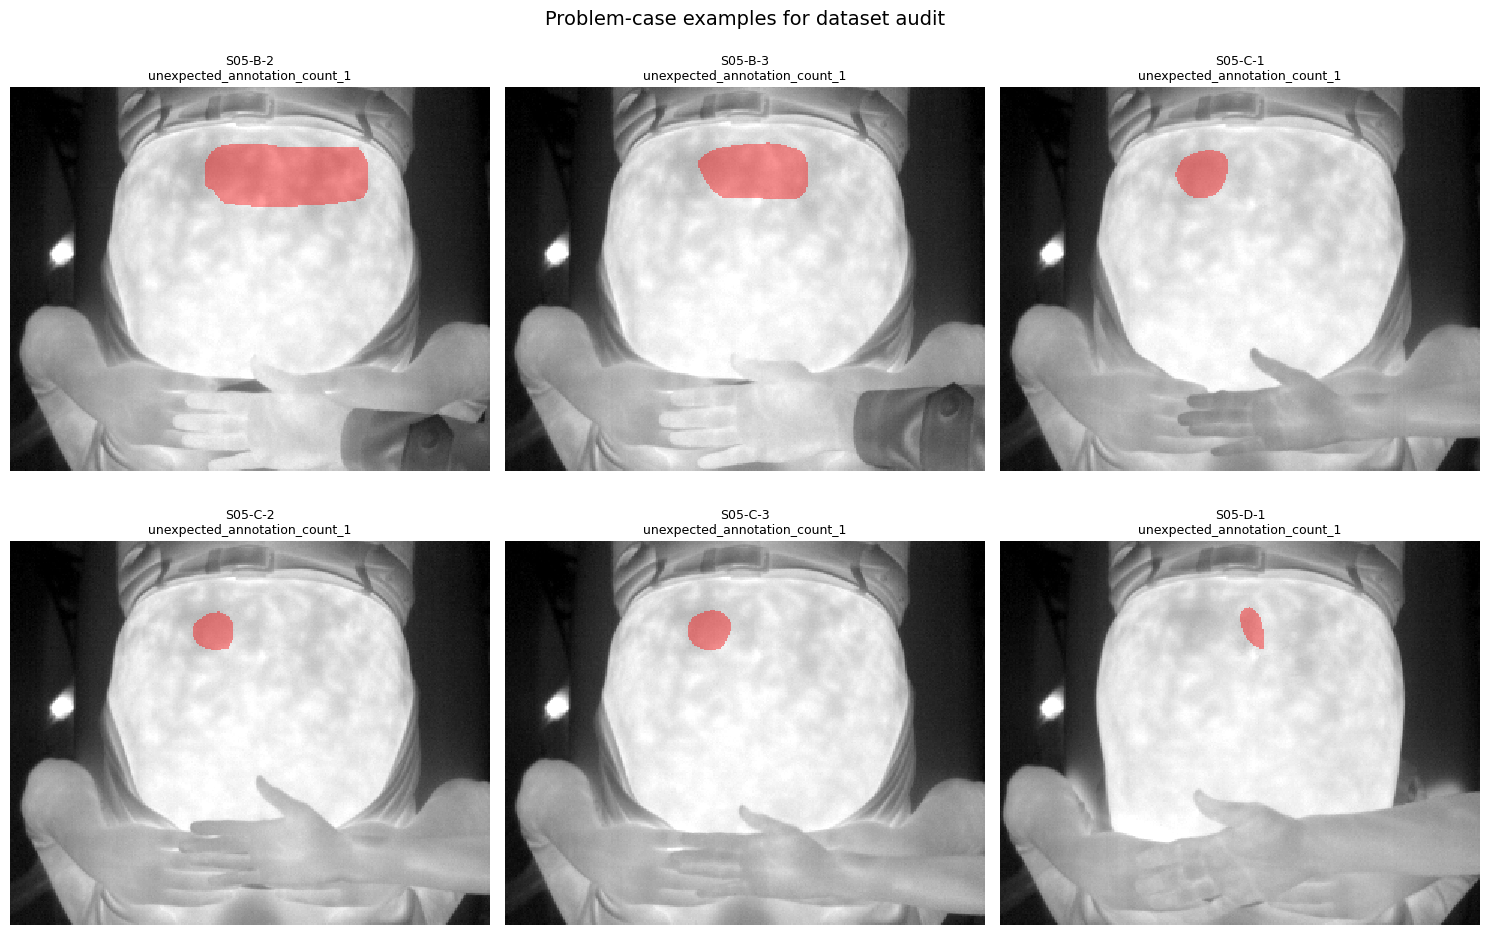

Saved: THERMO_DATASET_AUDIT/figures/fig_09_problem_case_examples.png


PosixPath('THERMO_DATASET_AUDIT/figures/fig_09_problem_case_examples.png')

In [12]:
# ============================================================
# SECTION 11 — PROBLEM CASE VISUALIZATION
# ============================================================

def visualize_problem_cases(max_cases=6):
    if "problem_df" in globals():
        p_df = problem_df.copy()
    elif (CSV_DIR / "09_problem_cases.csv").exists():
        p_df = pd.read_csv(CSV_DIR / "09_problem_cases.csv")
    else:
        print("No problem case table found.")
        return None

    if len(p_df) == 0:
        print("No problem cases detected.")
        return None

    p_df = p_df.head(max_cases)

    n = len(p_df)
    cols = min(3, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax in axes.ravel():
        ax.axis("off")

    for idx, (_, r) in enumerate(p_df.iterrows()):
        rr = idx // cols
        cc = idx % cols
        audit_case_id = r["audit_case_id"]
        g = pair_df[pair_df["audit_case_id"] == audit_case_id].copy()
        if len(g) == 0:
            continue
        g = sort_df(g, ["doctor_id", "doctor_try", "mask_name"])
        img = load_gray(g["image_path"].iloc[0])
        mask = np.rint(load_gray(g["mask_path"].iloc[0])).astype(np.int32)
        _, cold = mask_to_body_cold(mask)
        draw_mask_panel(axes[rr, cc], img, cold, f"{audit_case_id}\n{r['problem_type']}")

    plt.suptitle("Problem-case examples for dataset audit", fontsize=14)
    plt.tight_layout()
    save_path = FIG_DIR / "fig_09_problem_case_examples.png"
    plt.savefig(save_path, dpi=220)
    plt.show()
    print("Saved:", save_path)
    return save_path

visualize_problem_cases()

In [13]:
# ============================================================
# SECTION 12 — SUMMARY FOR SLIDES
# ============================================================

summary_rows = []

summary_rows.append({"item": "n_image_files", "value": len(image_paths)})
summary_rows.append({"item": "n_mask_files", "value": len(mask_paths)})
summary_rows.append({"item": "n_unique_thermal_image_groups", "value": pair_df["audit_case_id"].nunique()})
summary_rows.append({"item": "n_subjects", "value": pair_df["subject_id"].nunique()})
summary_rows.append({"item": "n_pair_rows", "value": len(pair_df)})
summary_rows.append({"item": "annotation_count_distribution", "value": json.dumps(pair_df.groupby("audit_case_id")["mask_path"].count().value_counts().sort_index().to_dict())})
summary_rows.append({"item": "doctor_ids_detected", "value": ",".join(map(str, sorted(pair_df["doctor_id"].unique(), key=natural_sort_string)))})
summary_rows.append({"item": "mean_body_pixels_per_annotation", "value": float(pixel_df["body_pixels"].mean()) if len(pixel_df) else np.nan})
summary_rows.append({"item": "mean_cold_pixels_per_annotation", "value": float(pixel_df["cold_pixels"].mean()) if len(pixel_df) else np.nan})
summary_rows.append({"item": "median_cold_pixels_per_annotation", "value": float(pixel_df["cold_pixels"].median()) if len(pixel_df) else np.nan})
summary_rows.append({"item": "mean_cold_fraction_in_body", "value": float(pixel_df["cold_fraction_in_body"].mean()) if len(pixel_df) else np.nan})

if "consensus_df" in globals() and len(consensus_df):
    summary_rows.append({"item": "mean_pairwise_cold_dice", "value": float(consensus_df["mean_pairwise_cold_dice"].mean())})
    summary_rows.append({"item": "mean_pairwise_cold_iou", "value": float(consensus_df["mean_pairwise_cold_iou"].mean())})
    summary_rows.append({"item": "mean_cold_uncertainty", "value": float(consensus_df["mean_cold_uncertainty"].mean())})

summary_rows.append({"item": "n_problem_rows", "value": len(problem_df) if "problem_df" in globals() else 0})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(CSV_DIR / "10_audit_summary_for_slides.csv", index=False)

display(summary_df)

print("Generated CSV files:")
for p in sorted(CSV_DIR.glob("*.csv")):
    print(" -", p.name)

print("\nGenerated figures:")
for p in sorted(FIG_DIR.glob("*.png")):
    print(" -", p.name)

,item,value
0,n_image_files,79
1,n_mask_files,79
2,n_unique_thermal_image_groups,79
3,n_subjects,7
4,n_pair_rows,79
5,annotation_count_distribution,"{""1"": 79}"
6,doctor_ids_detected,UNK
7,mean_body_pixels_per_annotation,15507.050633
8,mean_cold_pixels_per_annotation,1028.556962
9,median_cold_pixels_per_annotation,507.0


Generated CSV files:
 - 01_file_inventory.csv
 - 02_image_mask_pairing_check.csv
 - 03_patient_subject_case_doctor_try_table.csv
 - 04_duplicate_image_check.csv
 - 05_mask_label_value_check.csv
 - 06_mask_pixel_statistics.csv
 - 07_doctor_agreement_table.csv
 - 07b_consensus_cache_index.csv
 - 09_problem_cases.csv
 - 10_audit_summary_for_slides.csv

Generated figures:
 - fig_01_cases_per_subject.png
 - fig_02_annotations_per_same_image.png
 - fig_03_mean_cold_pixels_by_subject.png
 - fig_04_mean_cold_pixels_by_doctor.png
 - fig_05_agreement_by_subject.png
 - fig_09_problem_case_examples.png
